# Divvy station rebalancing: walkthrough

This notebook is the **explanation layer**. It does not compute anything the
pipeline doesn't. It reads the warehouse that `python -m divvy run` built and
shows the evidence for each stage (Classes 4–8).

Run the pipeline first:

```bash
python -m divvy run
```

In [1]:
import json, duckdb, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
con = duckdb.connect(str(ROOT / "warehouse/divvy.duckdb"), read_only=True)
q = lambda sql: con.execute(sql).df()
pd.set_option("display.max_columns", 30, "display.width", 200)

# Chart style: thin marks, recessive grid, neutral text ink; series colours used by role.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2,
})

## 1. Sources (Class 4)

The full map is in [`docs/01_source_map.md`](../docs/01_source_map.md). The critical
check is the **join key**: trip `station_id` matches GBFS `short_name`, not GBFS `station_id`.

In [2]:
q('''
select s.station_kind,
       count(*)                          as trip_station_ids,
       sum(s.trip_events_in_window)      as station_events,
       round(100 * sum(s.trip_events_in_window) / sum(sum(s.trip_events_in_window)) over (), 1) as pct_events
from model.dim_station s group by 1 order by station_events desc
''')

,station_kind,trip_station_ids,station_events,pct_events
0,docking_station,1149,3757871.0,96.3
1,public_rack,608,123794.0,3.2
2,not_in_gbfs,11,21966.0,0.6
3,staff_facility,3,19.0,0.0


## 2. Retrieval (Class 5)

Two external retrieval modes (file archives and the JSON API) feed a SQL warehouse.
Completeness is proven per month: bytes against Content-Length, a CRC test, and CSV rows against warehouse rows.

In [3]:
manifest = json.loads((ROOT / "data/raw/trips/manifest.json").read_text())
m = pd.DataFrame(manifest.values())[["month", "bytes", "sha256", "csv_rows", "retrieved_at"]]
m["sha256"] = m["sha256"].str[:12] + "…"
m["rows_in_warehouse"] = [con.execute("select count(*) from raw.trips where source_month = ?", [x]).fetchone()[0] for x in m.month]
m["reconciled"] = m.csv_rows == m.rows_in_warehouse
m

,month,bytes,sha256,csv_rows,retrieved_at,rows_in_warehouse,reconciled
0,2026-06,28468364,34bde1eddace…,762550,2026-09-24T10:09:11+00:00,762550,True
1,2026-07,32910286,4e6bc8725a92…,869051,2026-09-24T10:09:12+00:00,869051,True
2,2026-08,32611393,3f4de338ee56…,868191,2026-09-24T10:00:35+00:00,868191,True


In [4]:
snaps = sorted(p.name for p in (ROOT / "data/snapshots/gbfs").iterdir() if (p / "_meta.json").exists())
print(f"{len(snaps)} GBFS snapshots preserved verbatim: {snaps[0]} .. {snaps[-1]}")
q("select snapshot, count(*) stations, sum(num_bikes_available) bikes_available from raw.gbfs_station_status group by 1 order by 1")

3 GBFS snapshots preserved verbatim: 20260924T095605Z .. 20260924T100620Z


,snapshot,stations,bikes_available
0,20260924T095605Z,2059,6255.0
1,20260924T095619Z,2059,6255.0
2,20260924T100620Z,2059,6257.0


## 3. Profiling & validation (Class 6)

Every rule, its severity, and how many rows it touched. Nothing was deleted: rejected rows sit in
`staging.trips_rejected`, and flagged rows carry an `f_*` column. The reasoning for each rule is in
[`docs/03_validation_rules.md`](../docs/03_validation_rules.md).

In [5]:
pd.read_csv(ROOT / "outputs/validation_report.csv")[["rule_id", "severity", "description", "rows_affected", "pct", "passed", "action"]]

,rule_id,severity,description,rows_affected,pct,passed,action
0,F01,FLAG,Ride shorter than 60s (Divvy says these are re...,63490,2.5398,True,exclude from flows: same-dock re-docks / false...
1,F02,FLAG,Ride longer than 24h,2129,0.0852,True,keep departure; arrival kept but counted (like...
2,F03,FLAG,No end station and no end coordinates,2182,0.0873,True,"departure counts, no arrival (lost/stolen or u..."
3,F04,FLAG,Starts or ends at an operator facility,19,0.0008,True,exclude from flows: not customer demand
4,F05,FLAG,Coordinates outside Chicago service area,20,0.0008,True,"keep, counted"
5,F06,FLAG,rideable_type outside known domain,0,0.0000,True,"keep, counted"
6,F07,FLAG,member_casual outside known domain,0,0.0000,True,"keep, counted"
7,F08,FLAG,No start station (dockless e-bike undock),537293,21.4935,True,outside station-balance scope; reported as cov...
8,F09,FLAG,No end station (dockless e-bike park),558641,22.3475,True,outside station-balance scope; reported as cov...
9,F10,FLAG,Station id appears under more than one name,17,0.9844,True,identify stations by id only; canonical name f...


In [6]:
# Where does the station-less share come from? Almost entirely e-bikes.
q('''
select rideable_type,
       count(*) rides,
       round(100 * avg((start_station_id is null)::int), 1) as pct_no_start_station,
       round(100 * avg((end_station_id   is null)::int), 1) as pct_no_end_station,
       round(100 * avg(f_under_60s::int), 2)                as pct_under_60s
from staging.trips group by 1
''')

,rideable_type,rides,pct_no_start_station,pct_no_end_station,pct_under_60s
0,classic_bike,687993,0.0,0.3,0.0
1,electric_bike,1811799,29.7,30.7,3.5


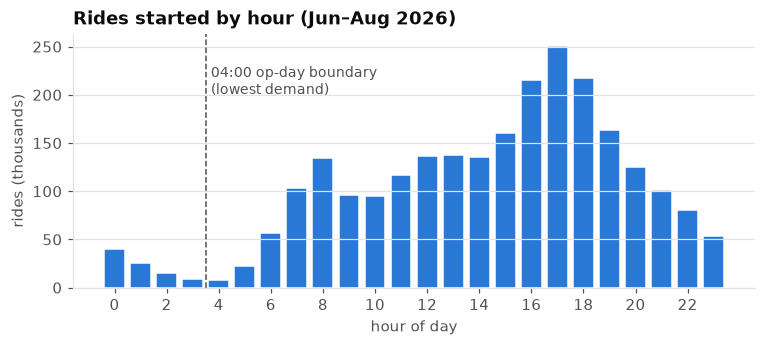

In [7]:
hourly = q("select hour(started_at) h, count(*) rides from staging.trips group by 1 order by 1")
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(hourly.h, hourly.rides / 1000, color=BLUE, width=0.8, edgecolor="white", linewidth=1)
ax.axvline(3.5, color=INK2, linestyle="--", linewidth=1)
ax.annotate("04:00 op-day boundary\n(lowest demand)", (3.7, hourly.rides.max() / 1000 * 0.8), color=INK2, fontsize=9)
ax.set(title="Rides started by hour (Jun–Aug 2026)", xlabel="hour of day", ylabel="rides (thousands)", xticks=range(0, 24, 2))
ax.grid(axis="x", visible=False)
plt.show()

## 4. Workflow model (Class 7)

`ride → station events (undock −1 / dock +1) → running balance per station-day → swing vs capacity`.
Below is one real station-day that the model flags, drawn the way the KPI sees it.

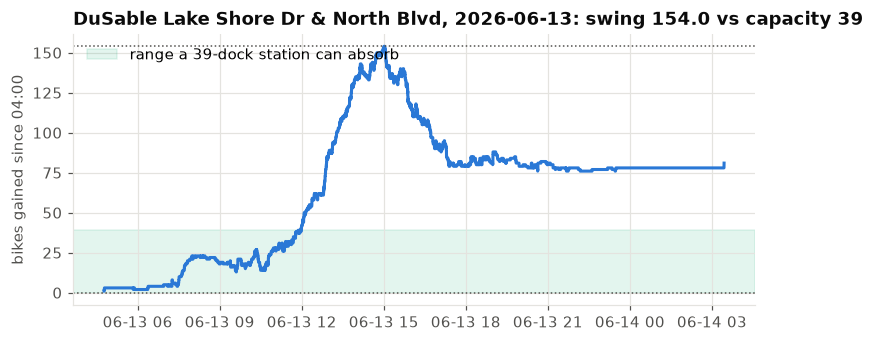

Even the best starting stock leaves 115 bikes that had to be moved (fill pressure).
A gain this far above capacity is only possible with valet overflow service: an intervention the data never logs.


In [8]:
ex = q('''
select station_id, op_date, capacity, swing, peak, trough, excess_moves, pressure
from model.station_day where in_kpi_scope and needs_rebalance
order by excess_moves desc limit 1''').iloc[0]
ev = q(f'''
select event_ts, sum(bike_delta) over (order by event_ts, bike_delta desc, ride_id) as running
from model.fact_station_event
where station_id = '{ex.station_id}' and op_date = date '{ex.op_date.date()}'
order by event_ts''')
name = con.execute("select station_name from model.dim_station where station_id = ?", [ex.station_id]).fetchone()[0]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.step(ev.event_ts, ev.running, where="post", color=BLUE)
ax.axhspan(ex.trough, ex.trough + ex.capacity, color=AQUA, alpha=0.12, label=f"range a {ex.capacity}-dock station can absorb")
ax.axhline(ex.peak, color=INK2, linewidth=1, linestyle=":")
ax.axhline(ex.trough, color=INK2, linewidth=1, linestyle=":")
ax.set(title=f"{name}, {ex.op_date.date()}: swing {ex.swing} vs capacity {ex.capacity}",
       ylabel="bikes gained since 04:00")
ax.legend(loc="upper left")
plt.show()
print(f"Even the best starting stock leaves {ex.excess_moves:.0f} bikes that had to be moved ({ex.pressure} pressure).")
print("A gain this far above capacity is only possible with valet overflow service: an intervention the data never logs.")

In [9]:
q('''select station_kind, count(*) station_days, round(100*avg(needs_rebalance::int),2) pct_needs_rebalance,
          sum(excess_moves) excess_moves from model.station_day group by 1''')

,station_kind,station_days,pct_needs_rebalance,excess_moves
0,docking_station,80410,1.64,10460.0
1,not_in_gbfs,491,NaN,0.0
2,public_rack,14109,NaN,0.0


## 5. Metrics (the KPI and M2–M5)

In [10]:
s = pd.read_csv(ROOT / "outputs/metrics_summary.csv")
s.pivot_table(index=["metric_id", "metric", "unit"], columns="month", values="value").reset_index()

month,metric_id,metric,unit,2026-06,2026-07,2026-08,ALL
0,M1,Rebalance-required station-day rate,%,1.49,1.78,1.66,1.64
1,M2,Minimum bike moves per day,bikes/day,114.70,129.42,100.23,114.95
2,M3,Top-50 station share of required moves,%,97.47,94.92,92.45,93.24
3,M4,Chronic imbalance stations,stations,7.00,7.00,5.00,6.00
4,M5,Dock-attributed ride coverage,%,63.33,61.41,60.40,61.65


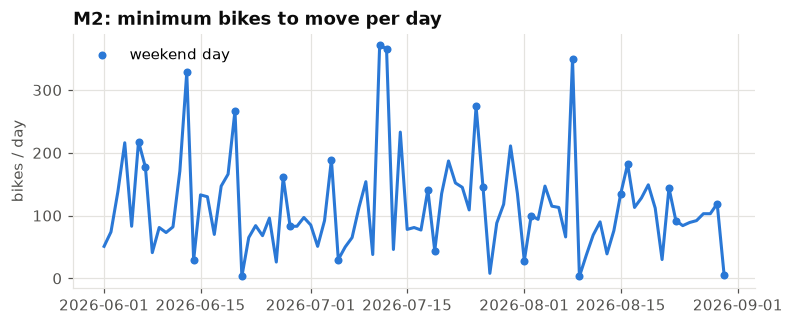

In [11]:
daily = pd.read_csv(ROOT / "outputs/daily_kpi.csv", parse_dates=["op_date"])
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(daily.op_date, daily.required_moves, color=BLUE)
wk = daily[daily.op_date.dt.dayofweek >= 5]
ax.scatter(wk.op_date, wk.required_moves, color=BLUE, s=18, zorder=3, label="weekend day")
ax.set(title="M2: minimum bikes to move per day", ylabel="bikes / day")
ax.legend(loc="upper left")
plt.show()

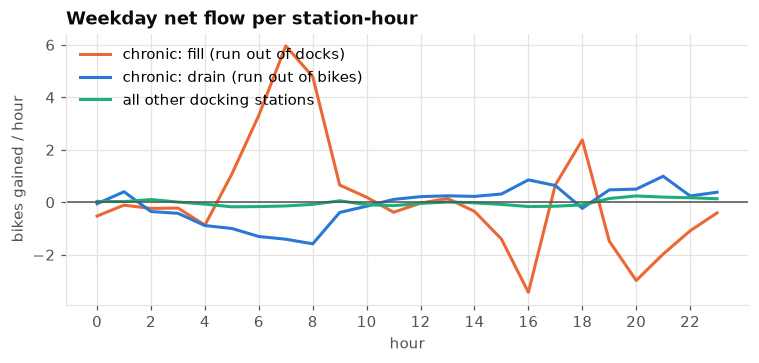

In [12]:
hp = pd.read_csv(ROOT / "outputs/hourly_profile.csv")
fig, ax = plt.subplots(figsize=(8, 3.2))
for grp, color, label in [("chronic_fill", ORANGE, "chronic: fill (run out of docks)"),
                          ("chronic_drain", BLUE, "chronic: drain (run out of bikes)"),
                          ("other", AQUA, "all other docking stations")]:
    d = hp[hp.station_group == grp]
    if len(d):
        ax.plot(d.hour, d.avg_net_flow_per_station_hour, color=color, label=label)
ax.axhline(0, color=INK2, linewidth=1)
ax.set(title="Weekday net flow per station-hour", xlabel="hour", ylabel="bikes gained / hour", xticks=range(0, 24, 2))
ax.legend(loc="upper left")
plt.show()

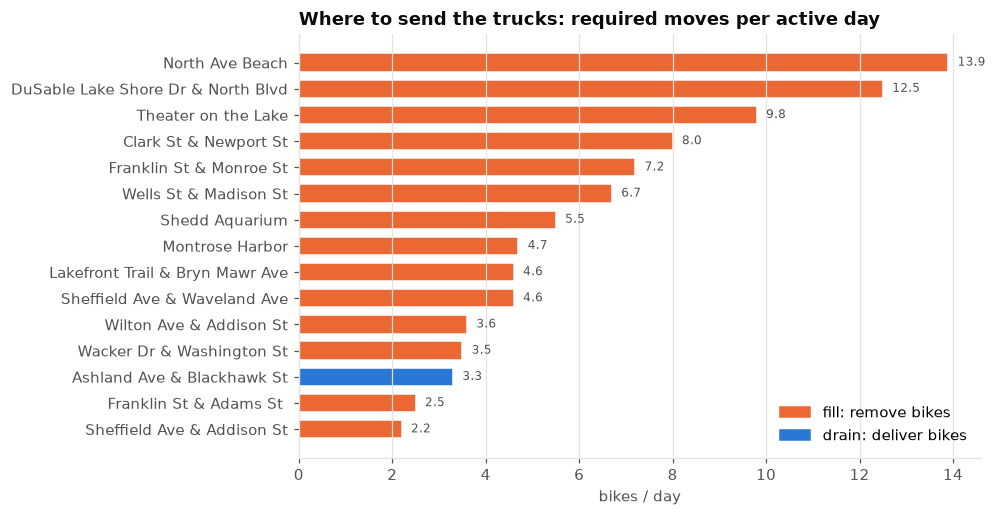

In [13]:
t = pd.read_csv(ROOT / "outputs/rebalancing_targets.csv").head(15).sort_values("required_moves_per_day")
fig, ax = plt.subplots(figsize=(8, 5))
colors = [ORANGE if p == "fill" else BLUE for p in t.dominant_pressure]
ax.barh(t.station_name, t.required_moves_per_day, color=colors, height=0.7, edgecolor="white", linewidth=1)
for y, v in enumerate(t.required_moves_per_day):
    ax.text(v + 0.2, y, f"{v:.1f}", va="center", color=INK2, fontsize=8)
ax.set(title="Where to send the trucks: required moves per active day", xlabel="bikes / day")
ax.grid(axis="y", visible=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ORANGE, label="fill: remove bikes"), Patch(color=BLUE, label="drain: deliver bikes")], loc="lower right")
plt.show()

In [14]:
# Corroboration: do stations the model calls chronic actually fail more in live data?
pd.read_csv(ROOT / "outputs/corroboration_gbfs.csv")

,station_group,stations_observed,status_observations,observed_empty_pct,observed_full_pct,observed_empty_or_full_pct
0,chronic (M4),6,18,50.0,16.7,66.7
1,other docking stations,1134,3402,7.8,4.6,12.4


## 6. Pipeline (Class 8)

Runs are audited in the warehouse. Every run, including a failed one, leaves a row here,
and `outputs/` is only replaced by a successful run.

In [15]:
q("select run_id, status, months, failed_step, error from audit.runs order by run_id desc limit 10")

,run_id,status,months,failed_step,error
0,20260924T100910Z,success,"2026-06,2026-07,2026-08",None,None
1,20260924T100634Z,success,2026-08,None,None


In [16]:
print(json.dumps({k: v for k, v in json.loads((ROOT / "outputs/last_run.json").read_text()).items()
                  if k in ("run_id", "status", "months", "step_seconds", "outputs")}, indent=2))

{
  "run_id": "20260924T100910Z",
  "months": [
    "2026-06",
    "2026-07",
    "2026-08"
  ],
  "status": "success",
  "step_seconds": {
    "ingest": 2.87,
    "load": 4.28,
    "validate": 3.35,
    "model": 2.96,
    "metrics": 0.11
  },
  "outputs": {
    "metrics_summary.csv": 20,
    "rebalancing_targets.csv": 50,
    "corroboration_gbfs.csv": 2,
    "hourly_profile.csv": 72,
    "daily_kpi.csv": 91,
    "validation_report.csv": 22
  }
}
